In [2]:
import pickle
import numpy as np
from collections import defaultdict
from pathlib import Path
from typing import Dict
import os
import pathlib
import random

import datasets
import numpy as np
import torch
import yaml
import os
import numpy as np
from litdata import optimize
from litdata.streaming import StreamingDataset, TokensLoader

/home/emilyx/miniconda3/envs/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_cluster_indices(assign_file: str, output_dir: str) -> Dict[int, np.ndarray]:
    """
    Load the assignment file and return a dictionary where the keys are cluster IDs
    and the values are numpy arrays of indices for each cluster. If the cluster indices
    are already saved, load them from the files.

    Args:
        assign_file (str): Path to the assignment.pkl file.
        output_dir (str): Directory to save/load the cluster indices.

    Returns:
        Dict[int, np.ndarray]: Dictionary with cluster IDs as keys and numpy arrays of indices as values.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Check if the cluster indices are already saved
    cluster_indices = {}
    for cluster_file in output_dir.glob('cluster_*.npy'):
        cluster_id = int(cluster_file.stem.split('_')[1])
        cluster_indices[cluster_id] = np.load(cluster_file)

    if cluster_indices:
        print(f"Loaded cluster indices from {output_dir}")
        return cluster_indices

    # Load the assignment.pkl file
    with open(assign_file, 'rb') as f:
        assignments = pickle.load(f)

    # Ensure assignments is a numpy array
    assignments = np.array(assignments)

    # Create a dictionary to store the indices for each cluster
    cluster_indices = defaultdict(list)

    # Iterate through the assignments and collect indices for each cluster
    for idx, cluster in enumerate(assignments.flatten()):
        cluster_indices[cluster].append(idx)

    # Convert lists to numpy arrays and save them
    cluster_indices = {cluster: np.array(indices) for cluster, indices in cluster_indices.items()}
    for cluster, indices in cluster_indices.items():
        np.save(output_dir / f'cluster_{cluster}.npy', indices)

    print(f"Saved cluster indices to {output_dir}")
    return cluster_indices

In [4]:
def collect_gradient_similarity_reward(num_clusters, cluster_indices):
    dataset = datasets.concatenate_datasets(
        [
            datasets.load_from_disk(
                f"/data/datasets/hf_cache/out/pythia-1b/fineweb/sample-350BT/random/step-00010000/less_full/{i}"
            )
            for i in range(32)
        ]
    )
    print(dataset)
    metrics = np.array(dataset["scores"]).reshape(-1)
    print(">> Metrics shape:", metrics.shape)

    cluster_average_reward = np.zeros(num_clusters)
    for cluster_id in range(num_clusters):
        indices = cluster_indices[cluster_id].astype("int32")
        indices = indices[indices < len(metrics)]
        cluster_average_reward[cluster_id] = np.mean(metrics[indices])
    np.save(pathlib.Path(base_dir, "average_reward.npy"), cluster_average_reward)
    return cluster_average_reward

In [5]:

base_dir = '/data/datasets/hf_cache/data/fineweb/sample-350BT/train_bge_micro_embeddings_index_1000'
assign_file = '/data/datasets/hf_cache/data/fineweb/sample-350BT/train_bge_micro_embeddings_index_1000/assignment.pkl'
cluster_indices_dir = '/data/datasets/hf_cache/data/fineweb/sample-350BT/train_bge_micro_embeddings_index_1000/cluster_indices'

cluster_indices = get_cluster_indices(assign_file, cluster_indices_dir)
cluster_average_reward = collect_gradient_similarity_reward(1000, cluster_indices)

Loaded cluster indices from /data/datasets/hf_cache/data/fineweb/sample-350BT/train_bge_micro_embeddings_index_1000/cluster_indices
Dataset({
    features: ['input_ids', 'scores'],
    num_rows: 1638400
})
>> Metrics shape: (1638400,)


In [7]:
dataset = datasets.concatenate_datasets(
    [
        datasets.load_from_disk(
            f"/data/datasets/hf_cache/out/pythia-1b/fineweb/sample-350BT/random/step-00010000/less_full/{i}"
        )
        for i in range(32)
    ]
)
print(dataset) # 409600
metrics = np.array(dataset["scores"]).reshape(-1)
# print averge of metrics
average_metrics = np.mean(metrics)
std_metrics = np.std(metrics)
print(f"Average of metrics: {average_metrics:.4f}")
print(f"Standard deviation of metrics: {std_metrics:.4f}")

Dataset({
    features: ['input_ids', 'scores'],
    num_rows: 1638400
})
Average of metrics: 0.0057
Standard deviation of metrics: 0.0235


In [11]:
sorted_cluster_ids = np.argsort(-cluster_average_reward)
cluster_sizes = []
cluster_rewards = []
cluster_std_devs = []

for cluster_id in sorted_cluster_ids:
    indices = cluster_indices[cluster_id].astype("int32")
    metric_indices = indices[indices < len(metrics)]
    cluster_rewards.append(metrics[metric_indices])
    cluster_sizes.append(len(indices))
    cluster_std_devs.append(np.std(metrics[metric_indices]))

for cluster_id, size, avg_reward, std_dev in zip(sorted_cluster_ids, cluster_sizes, cluster_average_reward[sorted_cluster_ids], cluster_std_devs):
    print(f"Cluster ID: {cluster_id}, Size: {size}, Average Reward: {avg_reward:.4f}, Std Dev: {std_dev:.4f}")

Cluster ID: 495, Size: 7450, Average Reward: 0.0261, Std Dev: 0.0239
Cluster ID: 521, Size: 482, Average Reward: 0.0226, Std Dev: 0.0282
Cluster ID: 26, Size: 14027, Average Reward: 0.0214, Std Dev: 0.0234
Cluster ID: 868, Size: 10989, Average Reward: 0.0207, Std Dev: 0.0260
Cluster ID: 575, Size: 10166, Average Reward: 0.0189, Std Dev: 0.0253
Cluster ID: 155, Size: 23651, Average Reward: 0.0188, Std Dev: 0.0242
Cluster ID: 678, Size: 17001, Average Reward: 0.0187, Std Dev: 0.0228
Cluster ID: 318, Size: 21623, Average Reward: 0.0174, Std Dev: 0.0237
Cluster ID: 464, Size: 15436, Average Reward: 0.0165, Std Dev: 0.0264
Cluster ID: 334, Size: 6161, Average Reward: 0.0163, Std Dev: 0.0218
Cluster ID: 829, Size: 18279, Average Reward: 0.0163, Std Dev: 0.0225
Cluster ID: 327, Size: 4058, Average Reward: 0.0162, Std Dev: 0.0236
Cluster ID: 989, Size: 7477, Average Reward: 0.0161, Std Dev: 0.0248
Cluster ID: 77, Size: 1102, Average Reward: 0.0158, Std Dev: 0.0276
Cluster ID: 34, Size: 6112, A

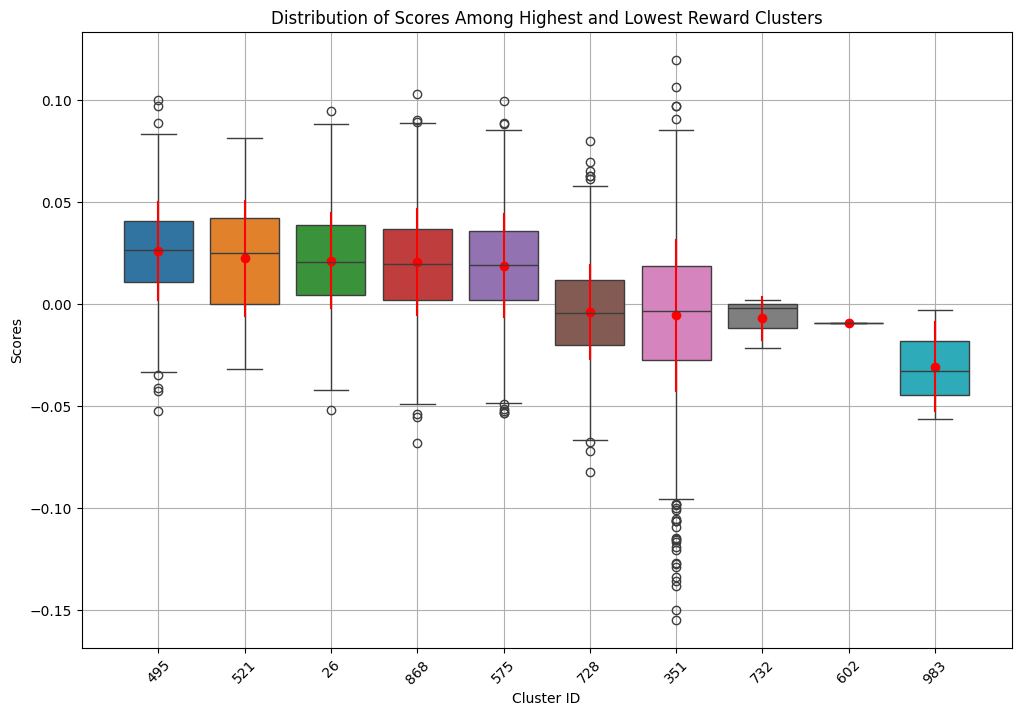

In [13]:
# Select the highest 5 and lowest 5 clusters
lowest_5_clusters = sorted_cluster_ids[:5]
highest_5_clusters = sorted_cluster_ids[-5:]
selected_clusters = np.concatenate([lowest_5_clusters, highest_5_clusters])

# Prepare data for box plot
box_plot_data = []
for cluster_id in selected_clusters:
    indices = cluster_indices[cluster_id].astype("int32")
    metric_indices = indices[indices < len(metrics)]
    cluster_scores = metrics[metric_indices]
    box_plot_data.append(cluster_scores)

# Create a box plot
plt.figure(figsize=(12, 8))
sns.boxplot(data=box_plot_data)
plt.xticks(ticks=np.arange(len(selected_clusters)), labels=selected_clusters, rotation=45)
plt.xlabel('Cluster ID')
plt.ylabel('Scores')
plt.title('Distribution of Scores Among Highest and Lowest Reward Clusters')
plt.grid(True)

# Add average and standard deviation markers
for i, cluster_id in enumerate(selected_clusters):
    avg_score = np.mean(box_plot_data[i])
    std_dev = np.std(box_plot_data[i])
    plt.plot(i, avg_score, 'ro')  # Red dot for average
    plt.plot([i, i], [avg_score - std_dev, avg_score + std_dev], 'r-')  # Red line for std deviation

plt.show()